# EMV PDF Extraction — Clean Pipeline (Stages 0 → 4)

This notebook implements a simple, auditable extraction pipeline for EMV PDFs using **pdfplumber**.

Stages included:
1. **Stage 0 — Profile & paths**
2. **Stage 1 — Page primitives** (words + lines)
3. **Stage 1.5 — Noise removal** (repeated headers/footers) → `clean_text`
4. **Stage 2 — Headings extraction** (regex + font size)
5. **Stage 3 — Tables extraction** (separate from body text)
6. **Stage 4 — Section Assembly**

In [1]:
# Stage 0 — Imports
import os
import re
import json
import math
import csv
import pdfplumber
import pandas as pd
from pathlib import Path
from IPython.display import display
from collections import Counter, defaultdict

## Stage 0 — Profile & output folders
Set up Profile and environement

In [2]:
PROFILE = {
    "doc_id": "EMV_Book_1",
    "doc_title": "EMV Integrated Circuit Card Specifications for Payment Systems — Book 1",
    "doc_version": "v4.4",              # update
    "doc_pages": None,
    "doc_date": "2022-12",              # update (YYYY-MM)
    "pdf_path": "../../../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_Interface.pdf",  # <-- update

    "out_root": "../../../data/processed/book1/",

    # Line building
    "line_top_tol": 5.0,          # cluster words into same line if tops are within this many points
    "line_x_gap": 2.0,            # add a space if the next word starts > this many points after prev word ends

    # Noise removal
    "header_ratio": 0.087, 
    "footer_ratio": 0.14, 
    "header_h_ratio": 0.132,         
    "footer_h_ratio": 0.15,         

    "noise_min_repetition": 0.30, # line must repeat on >= 60% of pages to be removed
    # Heading detection
    "heading_patterns": [
        r"^\s*(PART|Part)\s+[IVXLCDM]+\b.*$",         # PART I
        r"^\s*\d+(\.\d+)*\s+.+$",           # 1 / 1.1 / 1.1.1 Title
        r"^\s*(ANNEX|Annex)\s+[A-Z]\b.*$",    # Annex A ...
        r"^\s*[A-Z]\d+(\.\d+){0,2}\s+.+$",    # A1/ A1.1/ A1.1.1 Title
        #r"^\s*(FIGURE|Figure|TABLE|Table)\s+\d+.*$",  # Table 1 / Figure 1 ... 
    ],
    "table_title_patterns" : [
        r"^\s*Table\s+\d+[A-Za-z0-9\.\-]*\s*[:.\-]?\s+.+$",
        r"^\s*TABLE\s+\d+[A-Za-z0-9\.\-]*\s*[:.\-]?\s+.+$",
    ],
    # Definitions
    "definition_section_keywords": ["definitions", "terms and definitions", "terminology"],
    "definition_line_patterns": [
        r"^\s*([A-Za-z][A-Za-z0-9 /\-]{2,})\s*[:\-—]\s+(.+)$"
    ],
}

out_root = Path(PROFILE["out_root"])
(out_root / "pages").mkdir(parents=True, exist_ok=True)
(out_root / "pages" / "by_page").mkdir(parents=True, exist_ok=True)
(out_root / "tables").mkdir(parents=True, exist_ok=True)
(out_root / "headings").mkdir(parents=True, exist_ok=True)
(out_root / "definitions").mkdir(parents=True, exist_ok=True)

print("Output root:", out_root.resolve())


Output root: /app/src/data/processed/book1


In [3]:
def save_profile():
    profile_path = os.path.join(PROFILE["out_root"], "profile.json")
    with open(profile_path, "w", encoding="utf-8") as f:
        json.dump(PROFILE, f, ensure_ascii=False, indent=2)
save_profile()

# Stage 1 — Page Text Extraction (Words → Lines)

## What we do
- Extract **words** from each PDF page  
- Use word **position** and **font information**  
- Rebuild them into readable **text lines**
## Why
PDF text is not stored like a normal document.
It is saved as many small “word boxes”, each with:
- Coordinates on the page
- Font properties
- No real reading order

If we read it directly:

❌ Text appears broken  
❌ Sentences are scattered  
❌ Layout is lost  

This stage restores a natural reading structure so the document becomes usable.
## Technology Used

### pdfplumber

**What it is**  
A Python library specialized in reading and extracting content from PDFs.

**What we use it for**
- Reading PDF pages
- Extracting words with their:
  - Text content
  - Position on page (x, y coordinates)
  - Font size
  - Font name

**Key Function Used**

```python
page.extract_words()
```

**What this function returns**
A list of word dictionaries like:

[
  {
    "text": "Transaction",
    "x0": 72.3,
    "x1": 132.5,
    "top": 145.2,
    "bottom": 158.6,
    "fontname": "Helvetica-Bold",
    "size": 11.0
  }
]
## Output

For each page, we produce structured data:

**Text Content**

- Clean reconstructed text lines

- Natural reading flow

**Layout Metadata**

- Word positions

- Line bounding boxes

- Font size information

In [4]:
def normalize_ws(s: str) -> str:
    return re.sub(r"\s+", " ", s).strip()

def _safe_text(t):
    if t is None:
        return ""
    return str(t).strip()


def _get_meta_subset(w, keys):
    meta = {}
    for k in keys:
        if k in w and w[k] is not None:
            meta[k] = w[k]
    return meta


def words_to_lines(words, y_tol=4.0, join_with=" "):
    if not words:
        return []

    ws = []
    for idx, w in enumerate(words):
        try:
            # We keep the extraction metadata to help with gap detection
            ws.append({
                "_idx": idx,  
                "text": _safe_text(w.get("text", "")),
                "x0": float(w.get("x0", 0.0)),
                "x1": float(w.get("x1", 0.0)),
                "top": float(w.get("top", 0.0)),
                "bottom": float(w.get("bottom", 0.0)),
                "meta": _get_meta_subset(w, ["size", "fontname", "upright", "direction", "doctop"]),
            })
        except Exception:
            continue

    if not ws:
        return []

    # 1. Group words into horizontal row clusters based on 'top' coordinate
    row_clusters = []
    current = [ws[0]]
    current_top = ws[0]["top"]

    for w in ws[1:]:
        if abs(w["top"] - current_top) <= y_tol:
            current.append(w)
            # Update running average of the 'top' coordinate for the row
            current_top = (current_top * (len(current) - 1) + w["top"]) / len(current)
        else:
            row_clusters.append(current)
            current = [w]
            current_top = w["top"]
    row_clusters.append(current)

    lines = []

    # 2. Process each row to build the final text string with gap detection
    for row in row_clusters:
        if not row:
            continue

        # Within the row, words are already in reading order from pdfplumber
        text_parts = []
        for i in range(len(row)):
            current_w = row[i]
            text_parts.append(current_w["text"])
            
            # Check if there is a word following this one in the same line
            if i < len(row) - 1:
                next_w = row[i+1]
                
                # Calculate the horizontal gap between words
                gap = next_w["x0"] - current_w["x1"]
                
                # Dynamic Threshold Logic:
                # A standard space is roughly 0.25 to 0.3 of the font size.
                # 3 spaces is roughly 1.0 to 1.2 * font_size.
                font_size = current_w["meta"].get("size", 10.0)
                threshold = font_size * 1.1 
                
                if gap > threshold:
                    text_parts.append(" : ")
                else:
                    text_parts.append(join_with)

        # Build the final string and normalize whitespace
        raw_text = "".join(text_parts).strip()
        clean_text = re.sub(r"\s+", " ", raw_text)

        if not clean_text:
            continue

        # Calculate bounding box for the entire line
        x0 = min(w["x0"] for w in row)
        x1 = max(w["x1"] for w in row)
        top = min(w["top"] for w in row)
        bottom = max(w["bottom"] for w in row)

        # Extract metadata for the line (average font size)
        sizes = [w["meta"].get("size") for w in row if "size" in w["meta"]]
        meta = {"segment_words": int(len(row))}
        if sizes:
            try:
                meta["avg_size"] = float(sum(sizes) / len(sizes))
            except Exception:
                pass

        lines.append({
            "text": clean_text,
            "x0": x0,
            "x1": x1,
            "top": top,
            "bottom": bottom,
            "meta": meta,
            "word_count": len(row),
        })

    return lines

def extract_page_words(page):
    return page.extract_words(
        keep_blank_chars=False,
        use_text_flow=True,
        extra_attrs=["fontname", "size"]
    )


### Run Stage 1 extraction
Outputs:
- `pages/pages_raw.jsonl`
- `pages/pages_summary.csv`
- `pages/by_page/page_XXXX.json`


In [5]:
from datetime import datetime

raw_jsonl_path = out_root / "pages" / "pages_raw.jsonl"
summary_csv_path = out_root / "pages" / "pages_summary.csv"
by_page_dir = out_root / "pages" / "by_page"

records = []
summ_rows = []

with pdfplumber.open(PROFILE["pdf_path"]) as pdf:
    PROFILE["doc_pages"] = len(pdf.pages)
    print("Pages:", len(pdf.pages))
    for i, page in enumerate(pdf.pages, start=1):
        words = extract_page_words(page)
        lines = words_to_lines(words, y_tol=PROFILE["line_top_tol"])
        rec = {
            "doc_id": PROFILE["doc_id"],
            "doc_version": PROFILE["doc_version"],
            "doc_date": PROFILE["doc_date"],
            "page_num": i,
            "page_width": page.width,
            "page_height": page.height,
            "words": words,
            "lines": lines,
            "raw_text": "\n".join([l["text"] for l in lines]),
            "extracted_at": datetime.utcnow().isoformat() + "Z",
        }
        records.append(rec)
        (by_page_dir / f"page_{i:04d}.json").write_text(json.dumps(rec, ensure_ascii=False, indent=2), encoding="utf-8")
        summ_rows.append({
            "page_num": i,
            "n_words": len(words),
            "n_lines": len(lines),
            "raw_text_chars": len(rec["raw_text"]),
        })
save_profile()
with raw_jsonl_path.open("w", encoding="utf-8") as f:
    for rec in records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

pd.DataFrame(summ_rows).to_csv(summary_csv_path, index=False, encoding="utf-8")

print("Wrote:", raw_jsonl_path)
print("Wrote:", summary_csv_path)


Pages: 81
Wrote: ../../../data/processed/book1/pages/pages_raw.jsonl
Wrote: ../../../data/processed/book1/pages/pages_summary.csv


# Stage 1.5 — Noise Removal (Headers & Footers)

## What we do
- Detect repeated lines that appear on many pages
- Remove them automatically
- Focus on real content only

## Why
PDFs contain repeating noise like:

- Book titles
- Page numbers
- Copyright text
- Section banners

Outputs:
- `pages/noise_map.json`
- `pages/removed_lines_by_page.json`
- `pages/pages_clean.jsonl`


In [6]:
def line_in_header_or_footer(line, page_h, header_ratio, footer_ratio):
    if line.get("top") is None or line.get("bottom") is None:
        return False
    header_y = page_h * header_ratio
    footer_y = page_h * (1 - footer_ratio)
    return (line["bottom"] <= header_y) or (line["top"] >= footer_y)

def build_noise_map(page_records, min_rep):
    n_pages = len(page_records)
    counter = Counter()

    for rec in page_records:
        h, w = rec["page_height"], rec["page_width"]
        # Determine which ratio to use based on orientation
        current_h_ratio = PROFILE["header_ratio"] if h > w else PROFILE["header_h_ratio"]
        current_f_ratio = PROFILE["footer_ratio"] if h > w else PROFILE["footer_h_ratio"]

        for ln in rec["lines"]:
            if line_in_header_or_footer(ln, h, current_h_ratio, current_f_ratio):
                t = normalize_ws(ln["text"]).lower().strip()
                if t:
                    counter[t] += 1

    threshold = math.ceil(n_pages * float(min_rep))
    remove = {t for t, c in counter.items()}

    return {
        "n_pages": n_pages,
        "threshold_pages": threshold,
        "remove_texts": sorted(list(remove)),
        "counts": dict(counter),
    }

noise_map = build_noise_map(
    records,
    min_rep=PROFILE["noise_min_repetition"]
)

noise_map_path = out_root / "pages" / "noise_map.json"
noise_map_path.write_text(json.dumps(noise_map, ensure_ascii=False, indent=2), encoding="utf-8")
print("Wrote:", noise_map_path)
print("Remove candidates:", len(noise_map["remove_texts"]))


Wrote: ../../../data/processed/book1/pages/noise_map.json
Remove candidates: 120


In [7]:
clean_jsonl_path = out_root / "pages" / "pages_clean.jsonl"
remove_set = set(noise_map["remove_texts"])

def clean_page_lines(rec, remove_set):
    clean_lines = []
    removed = []
    for ln in rec["lines"]:
        t_norm = normalize_ws(ln["text"]).lower()
        h, w = rec["page_height"], rec["page_width"]
        current_h_ratio = PROFILE["header_ratio"] if h > w else PROFILE["header_h_ratio"]
        current_f_ratio = PROFILE["footer_ratio"] if h > w else PROFILE["footer_h_ratio"]
        if (
            t_norm in remove_set
            and line_in_header_or_footer(ln, h, current_h_ratio, current_f_ratio)
        ):
            removed.append(ln["text"])
            continue
        clean_lines.append(ln)
    return clean_lines, removed

clean_records = []
removed_log = []

for rec in records:
    clean_lines, removed = clean_page_lines(rec, remove_set)
    rec2 = dict(rec)
    rec2["clean_lines"] = clean_lines
    rec2["clean_text"] = "\n".join([l["text"] for l in clean_lines])
    clean_records.append(rec2)
    removed_log.append({"page_num": rec["page_num"], "removed_lines": removed})

with clean_jsonl_path.open("w", encoding="utf-8") as f:
    for rec in clean_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

(out_root / "pages" / "removed_lines_by_page.json").write_text(
    json.dumps(removed_log, ensure_ascii=False, indent=2), encoding="utf-8"
)

print("Wrote:", clean_jsonl_path)
print("Wrote:", out_root / "pages" / "removed_lines_by_page.json")


Wrote: ../../../data/processed/book1/pages/pages_clean.jsonl
Wrote: ../../../data/processed/book1/pages/removed_lines_by_page.json


# Stage 2 — Headings Extraction (Document Structure)

## What we do
Identify section titles using:

- Regex patterns  
- Font size (bigger text = likely heading)

Then:
- Order headings properly
- Build hierarchy (parent → child sections)
- Detect section spans across pages

## Why
Headings define the document structure:


Book
└── Section
└── Subsection
└── Paragraphs

This structure is critical for:
- Navigation  
- Section-level search  
- Accurate citations   
## Output
Structured heading records:
`headings/headings.json`

Each heading includes:
- Title text
- Level (section/subsection)
- Page location
- Parent section
- Covered page range


# Heading Processing — Function Summaries
### `looks_like_heading(...)`
Detects if a text line is likely a heading.  
It checks heading patterns and ensures the font size is large enough.  
Returns True/False with the detection reason.
### `infer_heading_level(...)`
Determines the hierarchy level of a heading from its numbering style.  
Recognizes Parts, Annexes, Sections, and nested subsections.  
Returns a numeric level (0 = highest level).
### `should_merge_heading_lines(...)`
Checks if two consecutive lines are parts of the same heading.  
Uses font size similarity, vertical distance, and heading patterns.  
Returns True if they should be merged.
### `merge_wrapped_heading_lines(...)`
Merges multi-line headings into a single complete heading.  
Combines text and updates position and font metadata.  
Returns a cleaned list of properly formed headings.

In [8]:
heading_res = [re.compile(p) for p in PROFILE["heading_patterns"]]

def looks_like_heading(text, font_avg, patterns):
    t = text.strip()
    if not t:
        return False, None

    matches_pattern = any(p.match(t) for p in patterns)
    has_large_font = False

    if font_avg is not None :
        if font_avg >= 12:
            has_large_font = True

    if matches_pattern and has_large_font and len(t) <= 160:
        return True, "regex_and_font"

    return False, None


def infer_heading_level(text):
    RE_LEVEL_4 = re.compile(r"^\s*([A-Z])\d+\.\d+\.\d+\s+.+$")
    RE_LEVEL_3 = re.compile(r"^\s*([A-Z])\d+\.\d+\s+.+$")
    RE_LEVEL_2 = re.compile(r"^\s*([A-Z])\d+\s+.+$")
    RE_NUMERIC = re.compile(r"^\s*(\d+(?:\.\d+)*)\s+.+$")

    t = text.strip()

    if re.match(r"^\s*(PART|Part)\s+[IVXLCDM]+\b.*$", t):
        return 0
    if re.match(r"^\s*(ANNEX|Annex)\s+[A-Z]\b.*$", t):
        return 1

    if RE_LEVEL_4.match(t):
        return 4
    if RE_LEVEL_3.match(t):
        return 3
    if RE_LEVEL_2.match(t):
        return 2

    m = RE_NUMERIC.match(t)
    if m:
        depth = m.group(1).count(".") + 1
        return min(depth, 6)

    return 2

def should_merge_heading_lines(curr, nxt, max_gap=50.0, size_tol=0.8):
    if not curr or not nxt:
        return False

    curr_text = curr["text"].strip()
    nxt_text = nxt["text"].strip()

    if not curr_text or not nxt_text:
        return False

    curr_size = curr.get("meta", {}).get("avg_size")
    nxt_size = nxt.get("meta", {}).get("avg_size")

    if curr_size is None or nxt_size is None:
        return False

    # similar font sizes
    if curr_size < 20 and nxt_size < 20:
        if abs(curr_size - nxt_size) > size_tol:
            return False
    elif curr_size >= 20 and nxt_size >= 20:
        if abs(curr_size - nxt_size) > 20:
            return False
    else:
        return False

    # heading-like font size
    if curr_size < 12 or nxt_size < 12:
        return False

    # vertically close
    curr_bottom = curr.get("bottom")
    nxt_top = nxt.get("top")
    if curr_bottom is None or nxt_top is None:
        return False

    if (nxt_top - curr_bottom) > max_gap:
        return False

    # current merged text must still look like a heading start
    first_is_heading, _ = looks_like_heading(
        curr_text,
        curr_size,
        heading_res
    )
    if not first_is_heading:
        return False

    # next line should not itself be a new standalone heading
    if any(p.match(nxt_text) for p in heading_res):
        return False

    return True


def merge_wrapped_heading_lines(lines, max_line_merge=3):
    merged = []
    i = 0

    while i < len(lines):
        curr = dict(lines[i])
        merged_count = 1
        j = i + 1

        while j < len(lines) and merged_count < max_line_merge:
            nxt = lines[j]

            if not should_merge_heading_lines(curr, nxt):
                break

            curr = {
                "text": f"{curr['text'].rstrip()} {nxt['text'].lstrip()}",
                "x0": min(curr.get("x0", 0), nxt.get("x0", 0)),
                "x1": max(curr.get("x1", 0), nxt.get("x1", 0)),
                "top": min(curr.get("top", 0), nxt.get("top", 0)),
                "bottom": max(curr.get("bottom", 0), nxt.get("bottom", 0)),
                "meta": {
                    "avg_size": max(
                        curr.get("meta", {}).get("avg_size", 0),
                        nxt.get("meta", {}).get("avg_size", 0)
                    )
                }
            }

            merged_count += 1
            j += 1

        merged.append(curr)
        i = j

    return merged

### `build_heading_ids_and_parents(...)`
Sorts headings in document order and gives each one a unique heading ID.  
Uses heading levels to find the parent heading of each section.  
Returns an enriched heading list with `heading_id` and `parent_heading_id`.

In [9]:
def build_heading_ids_and_parents(headings):
    # Ensure document order
    headings_sorted = sorted(
        headings,
        key=lambda h: (h["page_num"], h["bbox"]["top"] if h.get("bbox") else 0)
    )
    enriched = []
    stack = []  # keeps last seen headings by hierarchy

    for idx, h in enumerate(headings_sorted, start=1):
        h = dict(h)
        h["heading_id"] = (
            f"{h['doc_id']}_{h['doc_version']}"
            f"_p{h['page_num']:04d}_h{idx:04d}"
        )
        while stack and stack[-1]["level"] >= h["level"]:
            stack.pop()

        if stack:
            h["parent_heading_id"] = stack[-1]["heading_id"]
        else:
            h["parent_heading_id"] = None

        stack.append(h)
        enriched.append(h)

    return enriched

### `add_heading_spans(...)`
Determines the content range covered by each heading in the document.  
It finds where a heading starts and where it ends based on the next heading or page limits.  
Returns headings enriched with span info (`start_page/top`, `end_page/top`).

In [10]:
def add_heading_spans(headings, clean_records, last_page_num, min_text_len=3, footer_ratio=0.145):
    if not headings:
        return headings

    hs = sorted(
        headings,
        key=lambda h: (h["page_num"], h["bbox"]["top"] if h.get("bbox") else 0)
    )

    page_lines_map = {
        rec["page_num"]: rec.get("clean_lines", [])
        for rec in clean_records
    }

    page_height_map = {
        rec["page_num"]: rec.get("page_height")
        for rec in clean_records
    }

    def last_text_above_heading(page_num, heading_top):
        lines = page_lines_map.get(page_num, [])
        candidates = []

        for ln in lines:
            text = (ln.get("text") or "").strip()
            line_top = ln.get("top")
            line_bottom = ln.get("bottom")

            if not text or len(text) < min_text_len:
                continue
            if line_top is None or line_bottom is None:
                continue

            if line_bottom <= heading_top:
                candidates.append(ln)

        if not candidates:
            return None

        return max(candidates, key=lambda ln: ln.get("bottom", 0))

    def usable_page_bottom(page_num):
        page_h = page_height_map.get(page_num)
        if page_h is None:
            return None
        return page_h * (1 - footer_ratio)

    def find_next_boundary(idx):
        """
        Find the next heading that closes the current heading span.
        Rule: next heading with level <= current level.
        """
        curr_level = hs[idx]["level"]

        for j in range(idx + 1, len(hs)):
            if hs[j]["level"] <= curr_level:
                return hs[j]

        return None

    for i, h in enumerate(hs):
        h["start_page"] = h["page_num"]
        h["start_top"] = h["bbox"]["top"] if h.get("bbox") else None

        boundary_h = find_next_boundary(i)

        if boundary_h is not None:
            boundary_page = boundary_h["page_num"]
            boundary_top = boundary_h["bbox"]["top"] if boundary_h.get("bbox") else None

            if boundary_top is not None:
                last_line = last_text_above_heading(boundary_page, boundary_top)
            else:
                last_line = None

            if last_line is not None:
                h["end_page"] = boundary_page
                h["end_top"] = last_line.get("bottom")
            else:
                prev_page = max(h["start_page"], boundary_page - 1)
                h["end_page"] = prev_page
                h["end_top"] = usable_page_bottom(prev_page)
        else:
            h["end_page"] = last_page_num
            h["end_top"] = usable_page_bottom(last_page_num)

    return hs

This section scans all cleaned pages, detects lines that look like headings, and extracts their section number, title, level, and position.  
Then it adds parent-child links and the span covered by each heading, and saves everything into `headings.json`.  

### 📤 Output Example (`headings.json`)
```json
[
  {
    "doc_id": "EMV_BOOK3",
    "doc_version": "4.4",
    "doc_date": "2024-01-01",
    "page_num": 12,
    "section_number": "1.2",
    "title": "Application Selection",
    "level": 2,
    "reason": "regex_and_font",
    "bbox": {
      "x0": 72.1,
      "top": 145.3,
      "x1": 310.8,
      "bottom": 160.4
    },
    "font_size_avg": 14.0,
    "heading_id": "EMV_BOOK3_4.4_p0012_h0003",
    "parent_heading_id": "EMV_BOOK3_4.4_p0010_h0001",
    "start_page": 12,
    "start_top": 145.3,
    "end_page": 14,
    "end_top": 620.5
  }
]

In [11]:
headings = []
pattern_split = re.compile(r"^\s*(PART\s+[IVX]+|ANNEX\s+[A-Z]|[A-Z]?\d+(?:\.\d+)*)\s+(.+)$", re.I)
for rec in clean_records:
    lines = rec["clean_lines"]
    
    lines_for_heading = merge_wrapped_heading_lines(lines)

    for ln in lines_for_heading:
        ok, why = looks_like_heading(
            ln["text"],
            ln["meta"].get("avg_size"),
            heading_res
        )
        if ok:
            match = pattern_split.match(ln["text"])
            raw_title = match.group(2).strip()
            cleaned = re.sub(r"[^a-zA-Z0-9\s\-\(\)\,\.]", "", match.group(2))
            cleaned_title = re.sub(r"^[^a-zA-Z0-9]+", "", cleaned).strip()
            headings.append({
                "doc_id": rec["doc_id"],
                "doc_version": rec["doc_version"],
                "doc_date": rec["doc_date"],
                "page_num": rec["page_num"],
                "section_number": match.group(1),
                "title": cleaned_title,
                "level": infer_heading_level(ln["text"]),
                "reason": why,
                "bbox": {
                    "x0": ln.get("x0"),
                    "top": ln.get("top"),
                    "x1": ln.get("x1"),
                    "bottom": ln.get("bottom")
                },
                "font_size_avg": ln["meta"].get("avg_size"),            })
headings = build_heading_ids_and_parents(headings)
last_page = clean_records[-1]["page_num"]

headings = add_heading_spans(
    headings=headings,
    clean_records=clean_records,
    last_page_num=PROFILE["doc_pages"]
)
headings_path = out_root / "headings" / "headings.json"
headings_path.write_text(json.dumps(headings, ensure_ascii=False, indent=2), encoding="utf-8")

print("Headings:", len(headings))
print("Wrote:", headings_path)

Headings: 68
Wrote: ../../../data/processed/book1/headings/headings.json


# Stage 3 — Tables extraction
Tables are extracted separately to avoid mixing table structure into normal text.

Output: `tables/tables.json`


In [12]:
def table_to_text(cells):
    rows = []
    for r in cells or []:
        row = []
        for c in (r or []):
            row.append(normalize_ws(str(c)) if c is not None else "")
        rows.append(" | ".join(row))
    return "\n".join(rows).strip()

tables = []
table_settings = {
    "vertical_strategy": "lines",   # Use explicit lines for columns
    "horizontal_strategy": "lines", # Use explicit lines for rows
    "snap_tolerance": 6,            # Merge lines that are very close (fixes slight misalignment)
    "join_tolerance": 6,            # Join broken lines (crucial for indented vertical lines)
    "edge_min_length": 10,          # Ignore tiny line fragments/noise
    "intersection_tolerance": 5,    # Helps define cell corners in nested grids
}

In [13]:
title_res = [re.compile(p) for p in PROFILE["table_title_patterns"]]
def is_table_title(text, patterns=title_res):
    t = (text or "").strip()
    return any(p.match(t) for p in patterns)
def find_table_title_for_bbox(page_lines, table_bbox, max_gap=35):
    if not table_bbox:
        return None

    table_top = table_bbox["top"]
    table_bottom = table_bbox["bottom"]

    below_candidates = []
    above_candidates = []

    for ln in page_lines:
        text = (ln.get("text") or "").strip()
        if not text:
            continue
        if not is_table_title(text):
            continue

        ln_top = ln.get("top")
        ln_bottom = ln.get("bottom")
        if ln_top is None or ln_bottom is None:
            continue

        # title below table
        if 0 <= (ln_top - table_bottom) <= max_gap:
            below_candidates.append(ln)

        # title above table
        if 0 <= (table_top - ln_bottom) <= max_gap:
            above_candidates.append(ln)

    # prefer below, choose nearest
    if below_candidates:
        best = min(below_candidates, key=lambda ln: ln["top"] - table_bottom)
        return best["text"]

    # otherwise above, choose nearest
    if above_candidates:
        best = min(above_candidates, key=lambda ln: table_top - ln["bottom"])
        return best["text"]

    return None

In [14]:
tables = []
previous_table_title = None

page_lines_map = {
    rec["page_num"]: rec.get("clean_lines", [])
    for rec in clean_records
}

with pdfplumber.open(PROFILE["pdf_path"]) as pdf:
    for i, page in enumerate(pdf.pages, start=1):
        page_lines = page_lines_map.get(i, [])

        try:
            found = page.find_tables(table_settings)
        except Exception:
            found = []

        if found:
            for j, t in enumerate(found, start=1):
                cells = t.extract()
                if cells and len(cells)>1:
                    bbox = getattr(t, "bbox", None)
                    bbox_dict = {
                        "x0": bbox[0],
                        "top": bbox[1],
                        "x1": bbox[2],
                        "bottom": bbox[3]
                    } if bbox else None
    
                    table_title = find_table_title_for_bbox(page_lines, bbox_dict)
    
                    if not table_title:
                        table_title = previous_table_title
                    
                    tables.append({
                        "doc_id": PROFILE["doc_id"],
                        "doc_version": PROFILE["doc_version"],
                        "doc_date": PROFILE["doc_date"],
                        "page_num": i,
                        "table_id": f"p{i:04d}_t{j:02d}",
                        "bbox": bbox_dict,
                        "title": table_title,
                        "cells": cells,
                        "table_text": table_to_text(cells),
                    })
    
                    if table_title:
                        previous_table_title = table_title

tables_path = out_root / "tables" / "tables.json"
tables_path.write_text(json.dumps(tables, ensure_ascii=False, indent=2), encoding="utf-8")

print("Tables:", len(tables))
print("Wrote:", tables_path)

Tables: 20
Wrote: ../../../data/processed/book1/tables/tables.json


In [15]:
def build_dynamic_hierarchy(cells):
    if not cells or len(cells) < 2:
        return []

    def clean_text(x):
        if x is None:
            return ""
        return " ".join(str(x).split()).strip()

    def clean_header_name(h, idx):
        h = clean_text(h)
        if not h:
            return None
        h = "".join(c if c.isalnum() else "_" for c in h).lower().strip("_")
        return h if h else f"col_{idx}"

    header_row = cells[0]
    data_rows = cells[1:]

    # Step 1: normalize headers
    headers = [clean_header_name(h, i) for i, h in enumerate(header_row)]

    # Step 2: decide which columns to keep
    keep_cols = []
    for col_idx, header in enumerate(headers):
        col_values = []
        for row in data_rows:
            val = row[col_idx] if col_idx < len(row) else None
            col_values.append(clean_text(val))

        if header is not None:
            keep_cols.append(col_idx)
        else:
            if any(v != "" for v in col_values):
                keep_cols.append(col_idx)

    # Step 3: build final kept headers
    kept_headers = [headers[i] for i in keep_cols if headers[i] is not None]

    if not kept_headers:
        return []

    root = []
    stack = []

    for row in data_rows:
        if not row or all(clean_text(c) == "" for c in row):
            continue

        kept_values = []
        for col_idx in keep_cols:
            val = row[col_idx] if col_idx < len(row) else None
            kept_values.append(clean_text(val))

        if all(v == "" for v in kept_values):
            continue

        # nesting level = number of leading empty values
        level = 0
        for val in kept_values:
            if val == "":
                level += 1
            else:
                break

        row_content = [v for v in kept_values if v != ""]

        # Initialize an empty dict so we can control key insertion order
        node = {} 
        
        # 1. Map data keys (Tag, Value, Presence, etc.)
        for i, header in enumerate(kept_headers):
            node[header] = row_content[i] if i < len(row_content) else ""

        # 2. Add level metadata
        node["_level"] = level

        # 3. Add children last so it appears at the bottom of the JSON object
        node["children"] = []

        # hierarchy logic
        stack = stack[:level]

        if level == 0:
            root.append(node)
            stack = [node]
        elif stack:
            stack[-1]["children"].append(node)
            stack.append(node)
        else:
            root.append(node)
            stack = [node]

    return root

In [16]:
structured_tables = []

for table in tables:
    # Use the new dynamic function
    structured = build_dynamic_hierarchy(table.get("cells", []))
    table["structured_data"] = structured
    # table.pop("cells", None)
    # table.pop("table_text", None)
    structured_tables.append(table)
table_path = os.path.join(PROFILE["out_root"], "tables/structured_tables.json")
with open(table_path, "w", encoding="utf-8") as f:
    json.dump(structured_tables, f, indent=2, ensure_ascii=False)

### Example

Extracted Table Data:


,Name,Description,,Source,Format,Template,Tag,Length
0,Application\nLabel,Mnemonic associated with the AID\naccording to...,,ICC,ans with\nthe special\ncharacter\nlimited to\n...,'61' or 'A5','50',1–16
1,Application\nPreferred Name,Preferred mnemonic associated with\nthe AID,,ICC,ans (see\nsection 4.3),'61' or 'A5','9F12',1–16
2,Application\nPriority\nIndicator,Indicates the priority of a given\napplication...,,ICC,b,'61' or 'A5','87',1
3,Application\nSelection\nIndicator,For an application in the ICC to be\nsupported...,,Termina\nl,At the\ndiscretion of\nthe\nterminal.\nThe dat...,—,—,See\nFormat



Table Finder Debugging (Red lines = detected):


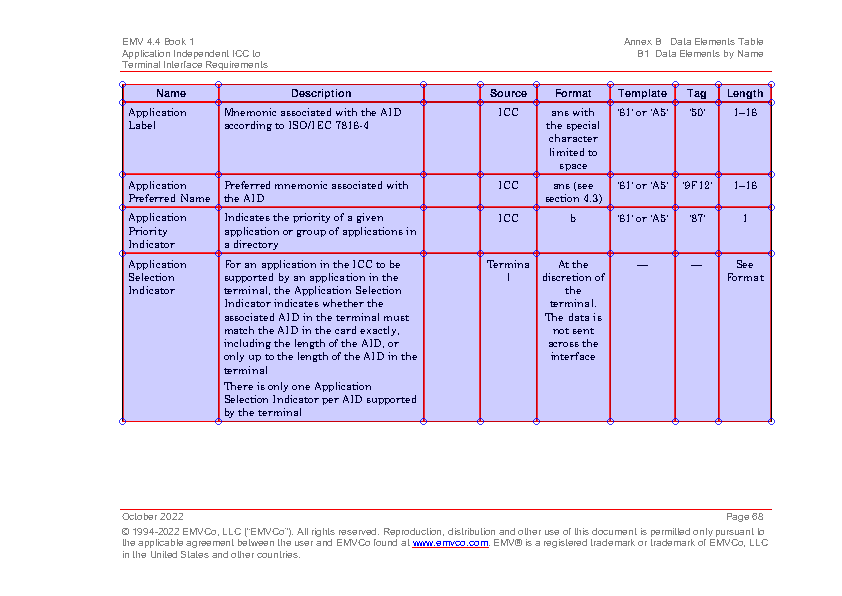

In [17]:
with pdfplumber.open(PROFILE["pdf_path"]) as pdf:
    p0 = pdf.pages[67]
    table = p0.extract_table(table_settings)
    exmpl_tab = pd.DataFrame(table[1:], columns=table[0])
    im = p0.to_image()
print("Extracted Table Data:")
display(exmpl_tab)
print("\nTable Finder Debugging (Red lines = detected):")
display(im.debug_tablefinder(table_settings))

# Stage 4 — Section Assembly

In this stage, we transition from a **page-based** representation of the document to a **section-based** structure. Instead of treating pages as independent units, we reconstruct the document into logical sections.

The section assembly relies on three main components extracted in previous stages:

1.  **Clean Records**: Text lines with spatial data (`bbox`) and page numbers.
2.  **Headings**: Metadata including hierarchy (`level`, `parent_id`) and physical span (`start_page` to `end_page`).
3.  **Tables**: Structured content (cells) and their location.

Each section is defined by a spatial boundaries:
* **Starts**: Immediately below its heading (`bbox.bottom`).
* **Ends**: At the start of the next detected heading (or document end).

To avoid noise in our data, we apply two filters:
* **Spatial Belonging**: Lines must fall within the `start_top` and `end_top` across the page range.
* **Deduplication**: Lines that fall inside a **table area** are excluded from the text blocks to prevent redundant data.

Each section maintains its full context path.
* *Example*: `["Part I", "Application Processing", "General Rules"]`
* This ensures that even a small subsection carries the context of its parent chapters.

Each section is stored as a self-contained JSON-like object:

```json
{
  "section_id": "EMV_Book_1_v4.4_10.2.2",
  "heading_id": "EMV_Book_1_v4.4_p0038_h0024",
  "title": "Application Selection",
  "doc_id": "EMV_Book_1",
  "doc_version": "v4.4",
  "doc_date": "2022-12",
  "section_number": "10.2.2",
  "level": 3,
  "parent_titles": ["Files, Commands, and Application Selection","Files","File Referencing"],
  "start_page": 12,
  "end_page": 14,
  "start_top": 145.77,
  "end_top": 455.636,
  "text_blocks": [
      {"page_num": 12, "text": "...", "bbox": {...}}
  ],
  "tables": [...],
  "full_text": "..." 
}
Output: `sections/sections.json`
        `sections/by_section/num_titles.json`

In [18]:
# Stage 4 — Section Assembly
(out_root / "sections").mkdir(parents=True, exist_ok=True)
(out_root / "sections" / "by_section").mkdir(parents=True, exist_ok=True)

tables_source = structured_tables if "structured_tables" in globals() else tables

def clean_inline_text(s):
    if s is None:
        return ""
    return re.sub(r"\s+", " ", str(s)).strip()

def safe_filename(s, max_len=120):
    s = clean_inline_text(s)
    s = re.sub(r"[^\w\s\-.]", "", s, flags=re.UNICODE)
    s = re.sub(r"\s+", "_", s).strip("._")
    return s[:max_len] if s else "section"

def build_parent_titles(heading, heading_by_id):
    titles = []
    parent_id = heading.get("parent_heading_id")
    while parent_id:
        parent = heading_by_id.get(parent_id)
        if not parent:
            break
        pt = clean_inline_text(parent.get("title", ""))
        if pt:
            titles.append(pt)
        parent_id = parent.get("parent_heading_id")
    return list(reversed(titles))

def build_parent_number(heading, heading_by_id):
    parent_id = heading.get("parent_heading_id")
    pt = None
    while parent_id:
        parent = heading_by_id.get(parent_id)
        if not parent:
            break
        parent_id = parent.get("parent_heading_id")
        pt = clean_inline_text(parent.get("section_number", ""))
    if pt:
        return pt
    return None

In [19]:
def line_belongs_to_heading_span(line, heading):
    page_num = line.get("_page_num")
    top = line.get("top")
    bottom = line.get("bottom")

    if page_num is None or top is None or bottom is None:
        return False

    start_page = heading.get("start_page")
    end_page = heading.get("end_page")
    start_top = heading.get("bbox", {}).get("bottom")  # content starts after heading line
    end_top = heading.get("end_top")

    if start_page is None or end_page is None:
        return False

    if page_num < start_page or page_num > end_page:
        return False

    if start_page == end_page:
        if start_top is not None and bottom < start_top:
            return False
        if end_top is not None and top > end_top:
            return False
        return True

    if page_num == start_page:
        if start_top is not None and bottom < start_top:
            return False
        return True

    if page_num == end_page:
        if end_top is not None and top > end_top:
            return False
        return True

    return True

def table_belongs_to_heading_span(table_obj, heading):
    page_num = table_obj.get("page_num")
    bbox = table_obj.get("bbox") or {}
    top = bbox.get("top")
    bottom = bbox.get("bottom")

    if page_num is None:
        return False

    start_page = heading.get("start_page")
    end_page = heading.get("end_page")
    start_top = heading.get("bbox", {}).get("bottom")
    end_top = heading.get("end_top")

    if start_page is None or end_page is None:
        return False

    if page_num < start_page or page_num > end_page:
        return False

    # if no bbox, page-level inclusion only
    if top is None or bottom is None:
        return True

    if start_page == end_page:
        if start_top is not None and bottom < start_top:
            return False
        if end_top is not None and top > end_top:
            return False
        return True

    if page_num == start_page:
        if start_top is not None and bottom < start_top:
            return False
        return True

    if page_num == end_page:
        if end_top is not None and top > end_top:
            return False
        return True

    return True

def line_belongs_to_table(line, table_obj):
    page_num_line = line.get("_page_num")
    top_line = line.get("top")
    bottom_line = line.get("bottom")

    page_num_tab = table_obj.get("page_num")
    bbox_tab = table_obj.get("bbox") or {}
    top_tab = bbox_tab.get("top")
    bottom_tab = bbox_tab.get("bottom")

    if page_num_line is None or page_num_tab is None:
        return False

    if top_line is None or bottom_line is None:
        return False

    if page_num_line != page_num_tab:
        return False

    if top_tab is None or bottom_tab is None:
        return False

    if bottom_line < top_tab:
        return False

    if top_line > bottom_tab:
        return False

    return True
def line_in_any_table(line, tables_source):
    for tb in tables_source:
        if line_belongs_to_table(line, tb):
            return True
    return False

In [20]:
def heading_to_section_id(h):
    doc_id = clean_inline_text(h.get("doc_id", "DOC")).replace(" ", "_")
    version = clean_inline_text(h.get("doc_version", "")).replace(" ", "_")
    sec_num = clean_inline_text(h.get("section_number", ""))
    if sec_num:
        safe_sec = re.sub(r"[^A-Za-z0-9\.]+", "_", sec_num).strip("_")
    else:
        safe_sec = clean_inline_text(h.get("heading_id", "section")).replace(" ", "_")
    return f"{doc_id}_{version}_{safe_sec}"

def section_to_filename(section, part=None):
    sec_num = clean_inline_text(section.get("section_number", ""))
    title = clean_inline_text(section.get("title", ""))
    if part and sec_num and title:
        base = f"{part} - {sec_num} - {title}"
    elif sec_num and title:
        base = f"{sec_num} - {title}"
    elif sec_num:
        base = sec_num
    elif title:
        base = title
    else:
        base = section.get("section_id", "section")

    return safe_filename(base) + ".json"

In [21]:
# add page number to lines for easier filtering
page_lines = []
for rec in clean_records:
    for ln in rec.get("clean_lines", []):
        ln2 = dict(ln)
        ln2["_page_num"] = rec["page_num"]
        page_lines.append(ln2)

heading_by_id = {h["heading_id"]: h for h in headings}

sections = []
by_section_dir = out_root / "sections" / "by_section"

for h in headings:
    section_lines = [ln for ln in page_lines if line_belongs_to_heading_span(ln, h) and not line_in_any_table(ln, tables_source)]
    section_tables = [t for t in tables_source if table_belongs_to_heading_span(t, h)]
    text_blocks = []
    for ln in section_lines:
        text_blocks.append({
            "page_num": ln["_page_num"],
            "text": ln.get("text", ""),
            "bbox": {
                "x0": ln.get("x0"),
                "top": ln.get("top"),
                "x1": ln.get("x1"),
                "bottom": ln.get("bottom")
            }
        })

    # include table titles + text in full_text
    full_parts = []
    for blk in text_blocks:
        txt = clean_inline_text(blk["text"])
        if txt:
            full_parts.append(txt)

    for tb in section_tables:
        if tb.get("title"):
            full_parts.append(clean_inline_text(tb["title"]))
        if tb.get("hierarchy_text"):
            full_parts.append(clean_inline_text(tb["hierarchy_text"]))
        elif tb.get("table_text"):
            full_parts.append(clean_inline_text(tb["table_text"]))
    
    section_obj = {
        "section_id": heading_to_section_id(h),
        "heading_id": h.get("heading_id"),
        "parent_heading_id": h.get("parent_heading_id"),
        "doc_id": h.get("doc_id"),
        "doc_version": h.get("doc_version"),
        "doc_date": h.get("doc_date"),
        "title": h.get("title", ""),
        "section_number": h.get("section_number", ""),
        "level": h.get("level"),
        "parent_titles": build_parent_titles(h, heading_by_id),
        "start_page": h.get("start_page"),
        "end_page": h.get("end_page"),
        "start_top": h.get("bbox", {}).get("top"),
        "end_top": h.get("end_top"),
        "text_blocks": text_blocks,
        "tables": section_tables,
        "full_text": "\n".join([p for p in full_parts if p]).strip()
    }

    sections.append(section_obj)
    part = build_parent_number(h, heading_by_id)
    # save one file per section
    base_name = section_to_filename(section_obj, part)
    section_file = by_section_dir / base_name
    counter = 1
    
    while section_file.exists():
        section_file = by_section_dir / f"{base_name.replace('.json', '')}_{counter}.json"
        counter += 1

    section_file.write_text(
        json.dumps(section_obj, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )

sections_path = out_root / "sections" / "sections.json"
sections_path.write_text(json.dumps(sections, ensure_ascii=False, indent=2), encoding="utf-8")

print("Sections:", len(sections))
print("Wrote:", sections_path)
print("Per-section files:", by_section_dir)

Sections: 68
Wrote: ../../../data/processed/book1/sections/sections.json
Per-section files: ../../../data/processed/book1/sections/by_section


# Stage 5 — Block Assembly Before Chunking

## Goal

Before chunking, we improve the internal structure of each section so that the content is grouped into **logical blocks** instead of isolated PDF lines.

This stage is important because chunking should not operate directly on raw lines. It should operate on stronger units such as:

- paragraphs
- bullet lists
- numbered rules
- notes / warnings attached to nearby rules
- tables as atomic units

## Why this matters

### Merge consecutive paragraph lines
A paragraph is usually spread across multiple PDF lines. If those lines are kept separate, chunking becomes noisy and meaning can be fragmented.

### Keep bullet lists together
Bullets often form a single logical unit and should remain grouped.

## Output

Each section will receive a new field:

```json
"content_blocks": [...]
```

Each block will contain:
- `block_type`
- `page_num`
- `bbox`
- `text`
- optional metadata such as `table_id`


In [22]:
# Stage 5 — Block Assembly Before Chunking

(out_root / "sections" / "assembled").mkdir(parents=True, exist_ok=True)

def detect_line_type(text):
    t = clean_inline_text(text)
    tl = t.lower()

    if not t:
        return "empty"

    if re.match(r"^[-•▪◦]\s+", t):
        return "bullet_list"

    if re.match(r"^\(?[0-9]+[\.\)]\s+", t) or re.match(r"^[A-Za-z][\.\)]\s+", t):
        return "numbered_rule"

    if tl.startswith("note") or tl.startswith("notes"):
        return "note"

    if tl.startswith("warning") or tl.startswith("caution"):
        return "warning"

    return "paragraph"

def merge_bbox(b1, b2):
    if not b1:
        return b2
    if not b2:
        return b1

    vals_x0 = [b1.get("x0"), b2.get("x0")]
    vals_top = [b1.get("top"), b2.get("top")]
    vals_x1 = [b1.get("x1"), b2.get("x1")]
    vals_bottom = [b1.get("bottom"), b2.get("bottom")]

    return {
        "x0": min(v for v in vals_x0 if v is not None) if any(v is not None for v in vals_x0) else None,
        "top": min(v for v in vals_top if v is not None) if any(v is not None for v in vals_top) else None,
        "x1": max(v for v in vals_x1 if v is not None) if any(v is not None for v in vals_x1) else None,
        "bottom": max(v for v in vals_bottom if v is not None) if any(v is not None for v in vals_bottom) else None,
    }

def should_merge_text_blocks(prev_blk, curr_blk, max_gap=6):
    if prev_blk["block_type"] != curr_blk["block_type"]:
        return False

    if prev_blk["block_type"] not in {"paragraph", "bullet_list", "numbered_rule"}:
        return False

    if prev_blk.get("page_num") != curr_blk.get("page_num"):
        return False

    prev_bbox = prev_blk.get("bbox") or {}
    curr_bbox = curr_blk.get("bbox") or {}

    prev_bottom = prev_bbox.get("bottom")
    curr_top = curr_bbox.get("top")
    prev_x0 = prev_bbox.get("x0")
    curr_x0 = curr_bbox.get("x0")

    if prev_bottom is None or curr_top is None:
        return False

    if curr_top - prev_bottom > max_gap:
        return False

    if prev_x0 is not None and curr_x0 is not None and abs(prev_x0 - curr_x0) > 20:
        return False

    return True

def assemble_section_blocks(section):
    raw_blocks = []

    for blk in section.get("text_blocks", []):
        if blk.get("block_type") == "table":
            raw_blocks.append({
                "block_type": "table",
                "page_num": blk.get("page_num"),
                "bbox": blk.get("bbox"),
                "table_id": blk.get("table_id"),
                "title": blk.get("title"),
                "text": clean_inline_text((blk.get("title") or "") + " " + (blk.get("text") or "")).strip()
            })
        else:
            txt = clean_inline_text(blk.get("text", ""))
            if not txt:
                continue
            raw_blocks.append({
                "block_type": detect_line_type(txt),
                "page_num": blk.get("page_num"),
                "bbox": blk.get("bbox"),
                "text": txt
            })

    merged = []
    for blk in raw_blocks:
        if not merged:
            merged.append(blk)
            continue

        prev = merged[-1]
        if should_merge_text_blocks(prev, blk):
            prev["text"] = clean_inline_text(prev["text"] + " " + blk["text"])
            prev["bbox"] = merge_bbox(prev.get("bbox"), blk.get("bbox"))
        else:
            merged.append(blk)

    attached = []
    for blk in merged:
        if blk["block_type"] in {"note", "warning"} and attached:
            prev = attached[-1]
            if prev["block_type"] in {"paragraph", "numbered_rule", "bullet_list"}:
                prev["attached_blocks"] = prev.get("attached_blocks", [])
                prev["attached_blocks"].append(blk)
                continue
        attached.append(blk)

    for blk in attached:
        parts = [clean_inline_text(blk.get("text", ""))]
        for sub in blk.get("attached_blocks", []):
            sub_txt = clean_inline_text(sub.get("text", ""))
            if sub_txt:
                parts.append(sub_txt)
        blk["full_block_text"] = "\n".join([p for p in parts if p]).strip()

    return attached

sections_assembled = []

for sec in sections:
    sec2 = dict(sec)
    sec2["content_blocks"] = assemble_section_blocks(sec2)
    sections_assembled.append(sec2)

assembled_path = out_root / "sections" / "assembled" / "sections_assembled.json"
assembled_path.write_text(json.dumps(sections_assembled, ensure_ascii=False, indent=2), encoding="utf-8")

print("Sections with assembled blocks:", len(sections_assembled))
print("Wrote:", assembled_path)


Sections with assembled blocks: 68
Wrote: ../../../data/processed/book1/sections/assembled/sections_assembled.json
